In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [4]:
# Hypothetically loading a dataset
df = pd.read_csv('Ice_cream selling data.csv')
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [5]:
df.shape

(49, 2)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='object')

In [11]:
#feature and target feature
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Define the degree of the polynomial
# You can adjust the degree as needed
poly = PolynomialFeatures(degree=2)  # y = m1x1 + m2(x2)2 + c 
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [13]:
# Initialize and fit the model
model = LinearRegression()
model.fit(X_poly_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Make predictions
y_pred = model.predict(X_poly_test)

In [15]:
y_pred

array([10.24499852, 25.82807714, 31.8241041 , 24.61704203,  4.43380256,
        4.00785672,  3.58277491,  3.17865087,  7.86990452,  2.91591368])

In [18]:
y_test

13    10.012868
45    17.843957
47    27.698383
44    28.912188
17     9.392969
27     2.313806
26     0.789974
25     4.625689
31     4.857988
19     4.673643
Name: Ice Cream Sales (units), dtype: float64

In [16]:
# Calculate Mean Squared Error or R² Score
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 14.878796440981484
R² Score: 0.843055137193884


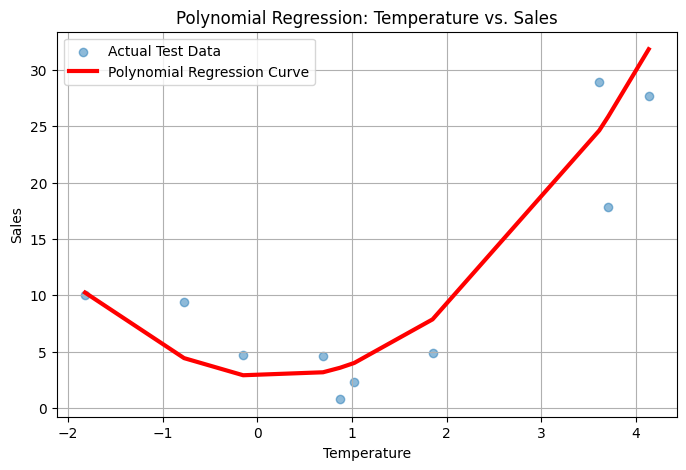

In [17]:
# To draw the curve, we sort the test data and predictions together
plot_df = pd.DataFrame({'X_test': X_test['Temperature (°C)'], 'y_pred': y_pred})
plot_df.sort_values(by='X_test', inplace=True)

# Create the plot
plt.figure(figsize=(8, 5))

# Plot the actual data as a scatter plot
plt.scatter(X_test, y_test, alpha=0.5, label='Actual Test Data')

# Plot the sorted predictions to form the curve
plt.plot(plot_df['X_test'], plot_df['y_pred'], color='red', linewidth=3, label='Polynomial Regression Curve')

plt.title('Polynomial Regression: Temperature vs. Sales')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()